In [5]:
from navierstokes import NavierStokesSolver
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(linewidth=np.inf)
np.set_printoptions(precision=3, suppress=True)

In [5]:
n1 = NavierStokesSolver(
    u=None, n_cols=129, n_rows=129,
    L_x=1,
    L_y=1,
    Re=100, 
    alpha_m=0.7, 
    alpha_p=0.3, 
    scheme='hybrid', 
    u_B = (0,0,1,0), 
    v_B=(0,0,0,0), 
    phi_B = (10, 100, 100, None))
n1.solve('m', threshold=1e-4)

C:\Users\nurei\AppData\Local\Temp\ipykernel_17100\1434427962.py:996: RuntimeWarning: divide by zero encountered in divide
  d_e = np.where(a_e != 0, (1/2) * (self._area_('e') / a_e + d_px), 0)
C:\Users\nurei\AppData\Local\Temp\ipykernel_17100\1434427962.py:997: RuntimeWarning: divide by zero encountered in divide
  d_w = np.where(a_w != 0, (1/2) * (self._area_('w') / a_w + d_px), 0)
C:\Users\nurei\AppData\Local\Temp\ipykernel_17100\1434427962.py:998: RuntimeWarning: divide by zero encountered in divide
  d_n = np.where(a_n != 0, (1/2) * (self._area_('n') / a_n + d_py), 0)
C:\Users\nurei\AppData\Local\Temp\ipykernel_17100\1434427962.py:999: RuntimeWarning: divide by zero encountered in divide
  d_s = np.where(a_s != 0, (1/2) * (self._area_('s') / a_s + d_py), 0)


Iteration: 783, u_err: 3.577e-05, v_err: 3.069e-05, p'_err: 3.351e-05
Finished with total error 9.997322570794395e-05


(array([[   nan,  1.   ,  1.   , ...,  1.   ,  1.   ,    nan],
        [ 0.   ,  0.271,  0.367, ...,  0.4  ,  0.284,  0.   ],
        [ 0.   , -0.003,  0.01 , ...,  0.05 ,  0.012,  0.   ],
        ...,
        [ 0.   ,  0.   ,  0.   , ...,  0.   ,  0.   ,  0.   ],
        [ 0.   ,  0.   ,  0.   , ...,  0.   ,  0.   ,  0.   ],
        [   nan,  0.   ,  0.   , ...,  0.   ,  0.   ,    nan]]),
 3.5770853813473154e-05,
 array([[   nan,  0.   ,  0.   , ...,  0.   ,  0.   ,    nan],
        [ 0.   ,  0.165,  0.126, ..., -0.129, -0.171,  0.   ],
        [ 0.   ,  0.295,  0.282, ..., -0.318, -0.328,  0.   ],
        ...,
        [ 0.   , -0.   , -0.   , ...,  0.   ,  0.   ,  0.   ],
        [ 0.   , -0.   , -0.   , ...,  0.   ,  0.   ,  0.   ],
        [   nan,  0.   ,  0.   , ...,  0.   ,  0.   ,    nan]]),
 3.069378683059715e-05,
 array([[   nan, -3.058, -1.258, ...,  2.023,  3.956,    nan],
        [-3.058, -3.058, -1.258, ...,  2.023,  3.956,  3.956],
        [-1.639, -1.639, -1.043, ...,  

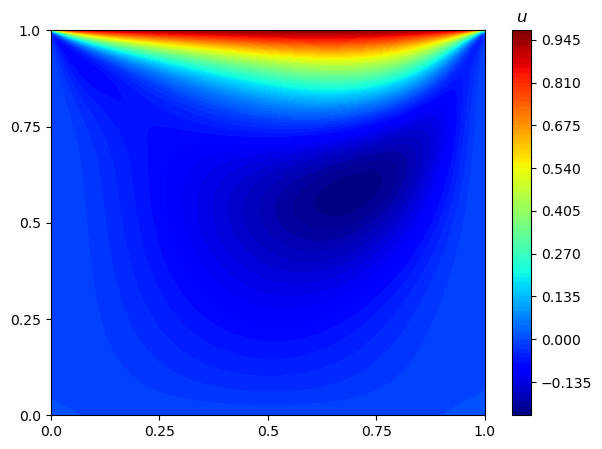

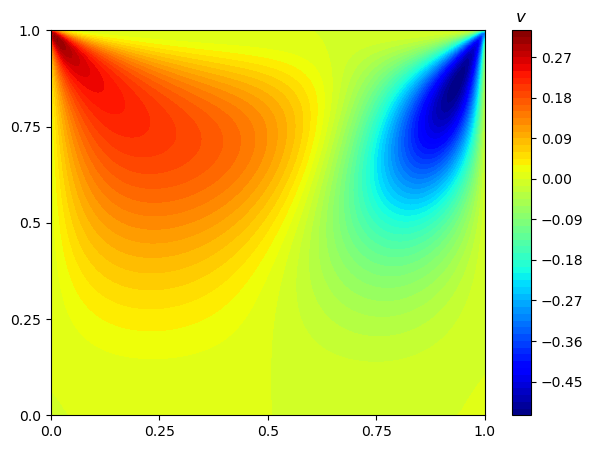

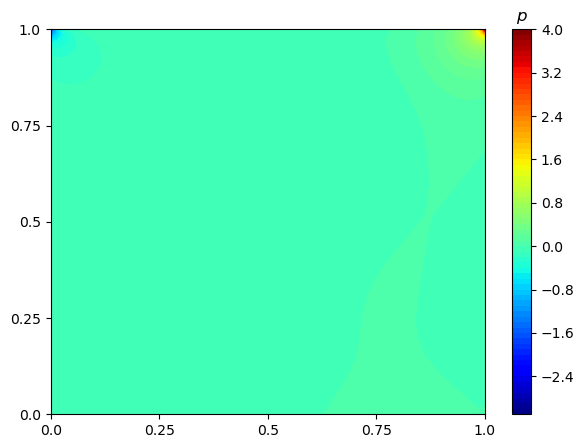

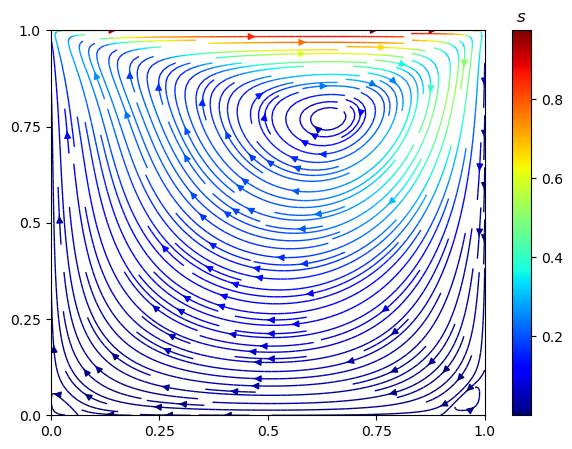

In [6]:
n1.plot('u', levels=80, streamlines=0)
n1.plot('v', levels=80, streamlines=0)
n1.plot('p', levels=80, streamlines=0)
n1.plot(None, levels=0, streamlines=2)

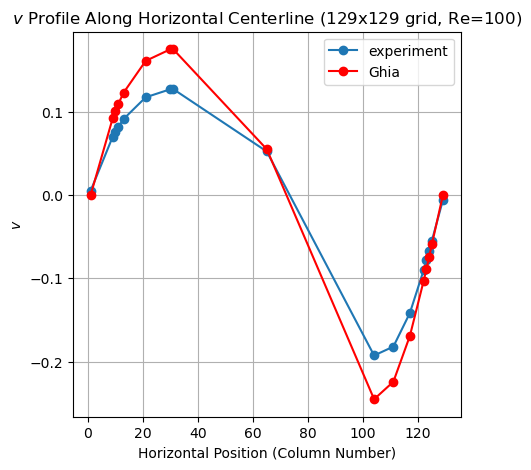

In [10]:
center_row = len(n1.x['v']) // 2
x = np.array([1,9,10,11,13,21,30,31,65,104,111,117,122,123,124,125,129]) 
vref = np.array([0, 0.092, 0.101, 0.109, 0.123, 0.161, 0.175, 0.175, 0.055, -0.245, -0.224, -0.169, -0.103, -0.089, -0.074, -0.059, 0])
velocity_profile = n1.x['v'][center_row, x]

plt.figure(figsize=(5,5))
plt.plot(x, velocity_profile, marker='o', label="experiment")  
plt.plot(x, vref, marker="o", color='r', label = "Ghia")

plt.title("$v$ Profile Along Horizontal Centerline (129x129 grid, Re=100)")
plt.xlabel("Horizontal Position (Column Number)")
plt.ylabel("$v$")
plt.grid()
plt.legend()
plt.show()

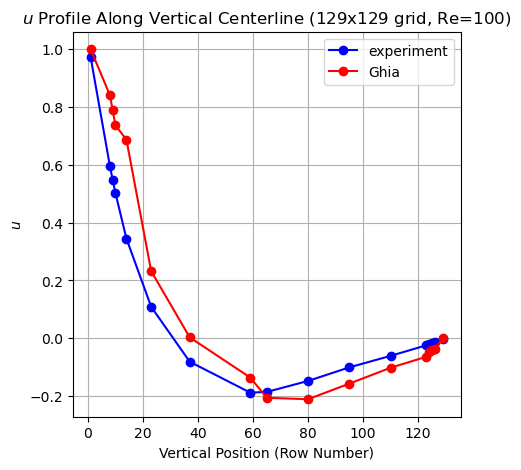

In [11]:
rows = np.array([1,8,9,10,14,23,37,59,65,80,95,110,123,124,125,126,129])[::-1]
uref = np.array([0, -0.037, -0.042, -0.048, -0.064, -0.102, -0.157, -0.211, -0.206, -0.136, 0.003, 0.232, 0.687, 0.737, 0.789, 0.841, 1])

center_col = n1.x['u'].shape[1] // 2


velocity_profile = n1.x['u'][rows, center_col]
plt.figure(figsize=(5,5))
plt.plot(rows, velocity_profile, marker='o', color='b', label="experiment")  
plt.plot(rows, uref, marker="o", color='r', label = 'Ghia')

plt.title(f"$u$ Profile Along Vertical Centerline (129x129 grid, Re={n1.Re})")
plt.xlabel(f"Vertical Position (Row Number)")
plt.ylabel(f"$u$")
plt.grid()
plt.legend()
plt.show()

In [ ]:

n2 = NavierStokesSolver(
    n_rows=100, 
    n_cols=100,
    Re=200, 
    u_B=(0,0,1,0), 
    v_B=(0,0,0,0), 
    scheme='central_difference', 
    obstacle_coords=[((0,0), (1/3, 1/3))])

n2.solve('m', threshold=1e-4)


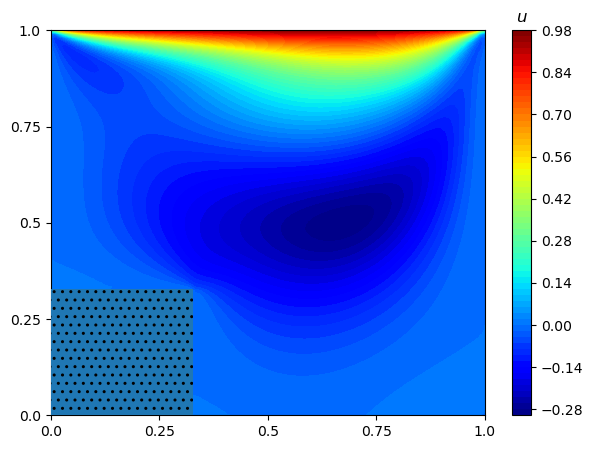

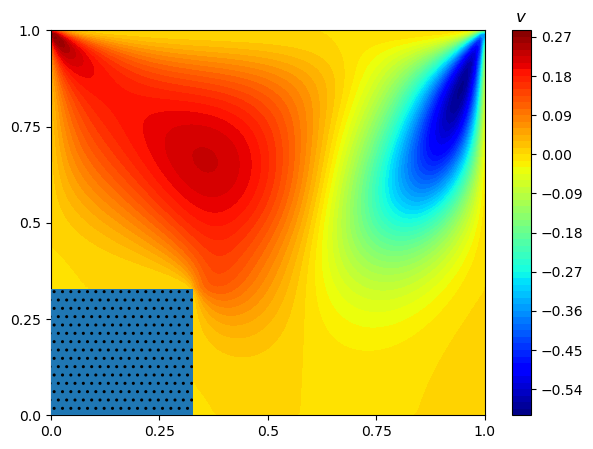

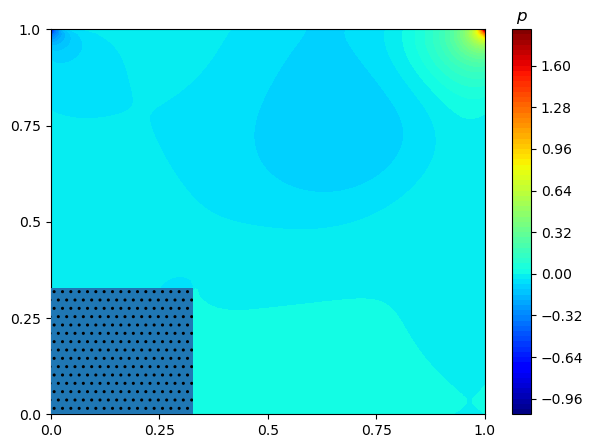

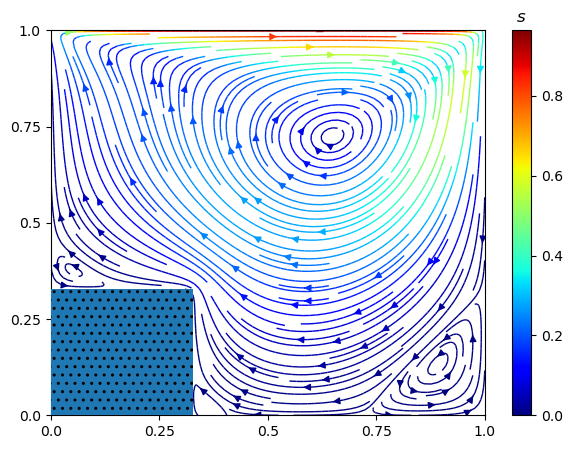

In [184]:
n2.plot('u', levels=80, streamlines=0)
n2.plot('v', levels=80, streamlines=0)
n2.plot('p', levels=80, streamlines=0)
n2.plot(None, levels=0, streamlines=2)

In [394]:
L=1
n3 = NavierStokesSolver(
    scheme='central_difference', 
    L_x=2*L, L_y=L/4, 
    u_B=(None,1,0,0), 
    v_B=(None, 0,0,0),
    p_B=(0, None, None, None),
    obstacle_coords=[((0,0), (L, L/8))],
    Re=100, 
    n_rows=30, n_cols=240)

In [ ]:
n3.solve('m', threshold=1e-4)

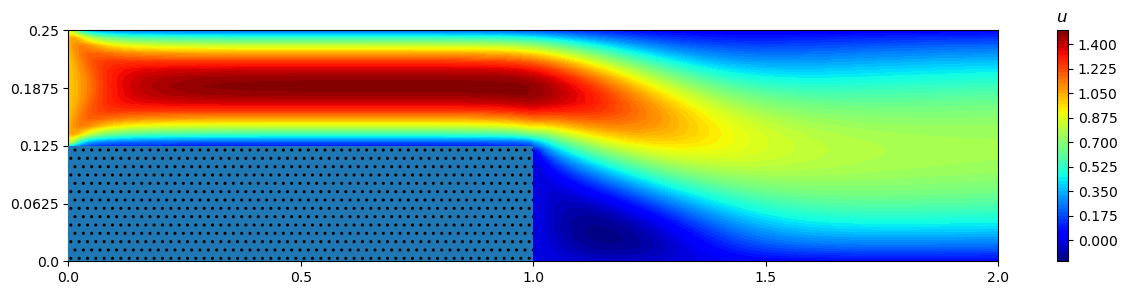

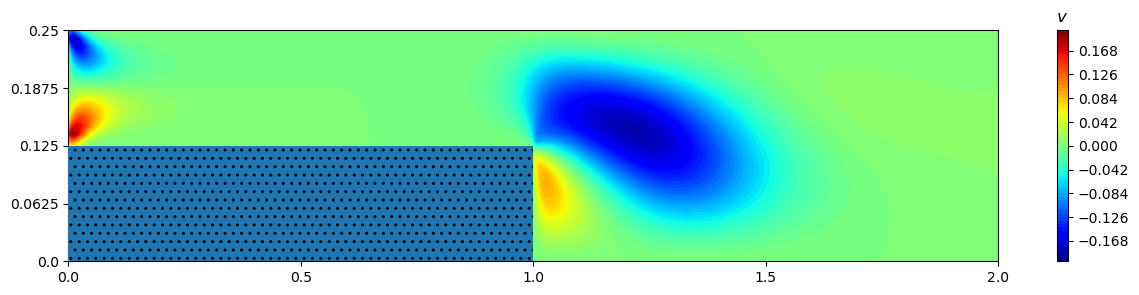

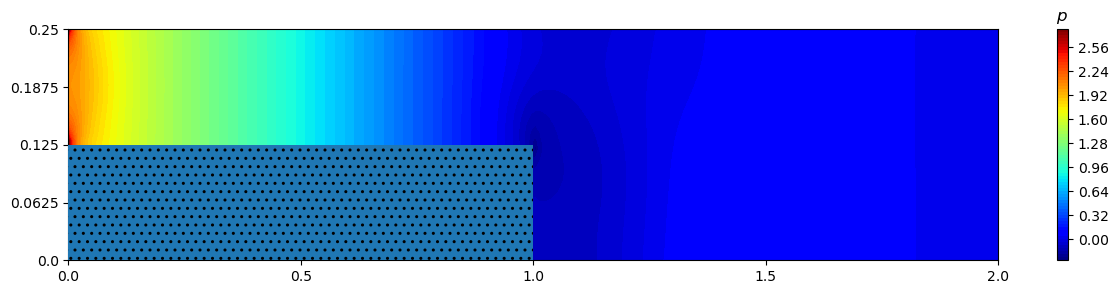

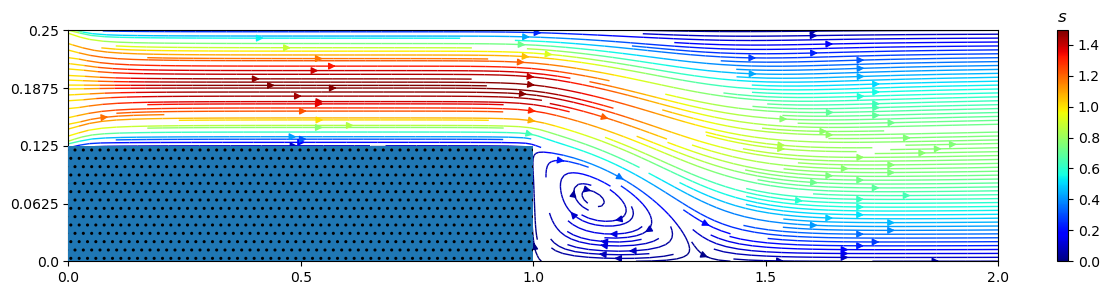

In [397]:
n3.plot('u', levels=80, streamlines=0, figsize=(15, 3))
n3.plot('v', levels=80, streamlines=0, figsize=(15, 3))
n3.plot('p', levels=80, streamlines=0, figsize=(15, 3))
n3.plot(None, levels=0, streamlines=2, figsize=(15, 3))

In [ ]:
L=1
n4 = NavierStokesSolver(
    scheme='central_difference', 
    L_x=2*L, L_y=L/4, 
    u_B=(None,1,0,0), 
    v_B=(None, 0,0,0),
    p_B=(0, None, None, None),
    obstacle_coords=[((0,0), (L, L/8))],
    Re=200, 
    n_rows=30, n_cols=240)

n4.solve('m', threshold=1e-4)

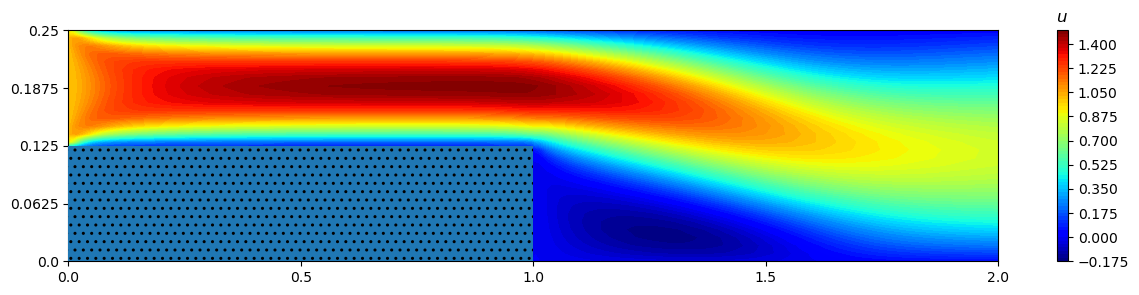

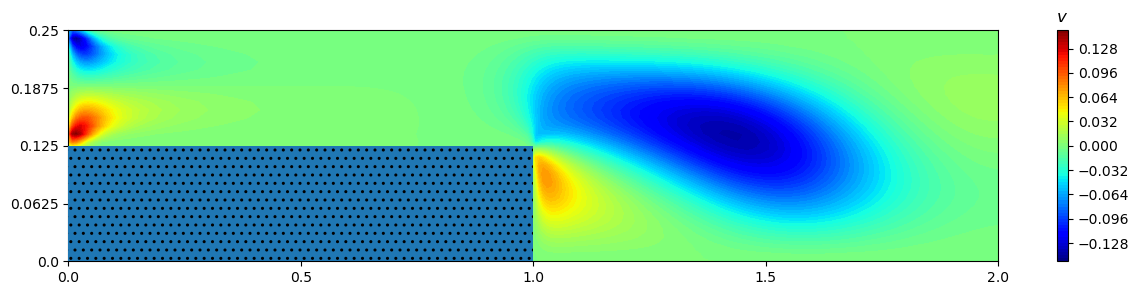

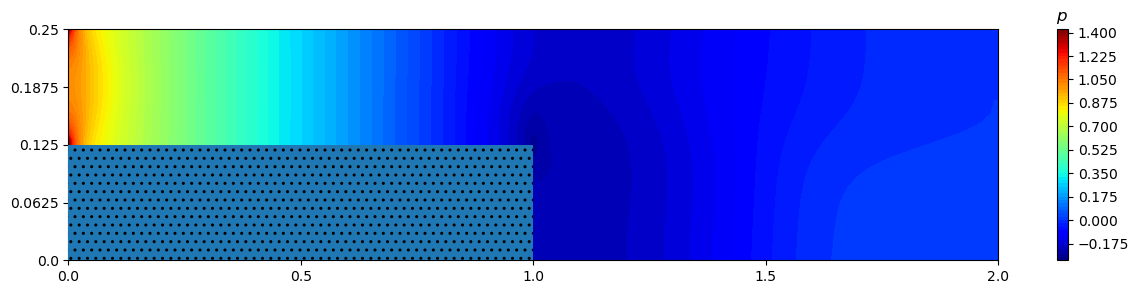

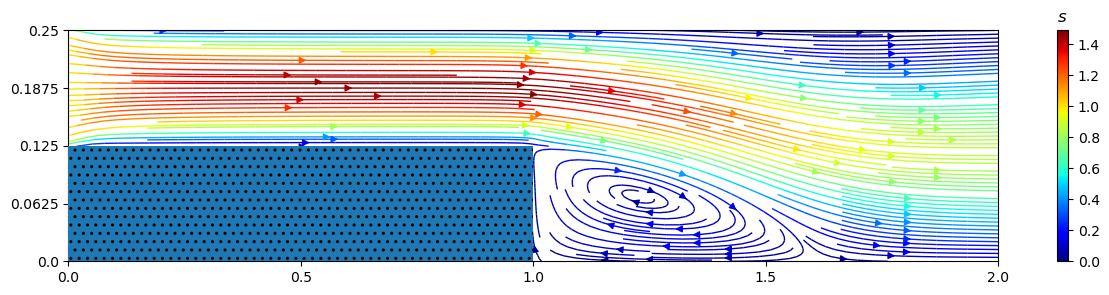

In [404]:

n4.plot('u', levels=80, streamlines=0, figsize=(15, 3))
n4.plot('v', levels=80, streamlines=0, figsize=(15, 3))
n4.plot('p', levels=80, streamlines=0, figsize=(15, 3))
n4.plot(None, levels=0, streamlines=2, figsize=(15, 3))

In [ ]:
L=1
n5 = NavierStokesSolver(
    scheme='central_difference', 
    L_x=2*L, L_y=L/4, 
    u_B=(None,1,0,0), 
    v_B=(None, 0,0,0),
    p_B=(0, None, None, None),
    obstacle_coords=[((0,0), (L, L/8))],
    Re=400, 
    n_rows=30, n_cols=240)
n5.solve('m', threshold=1e-4)

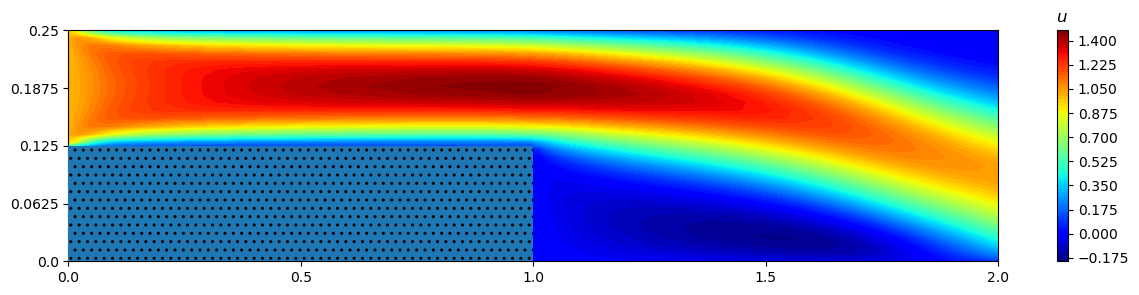

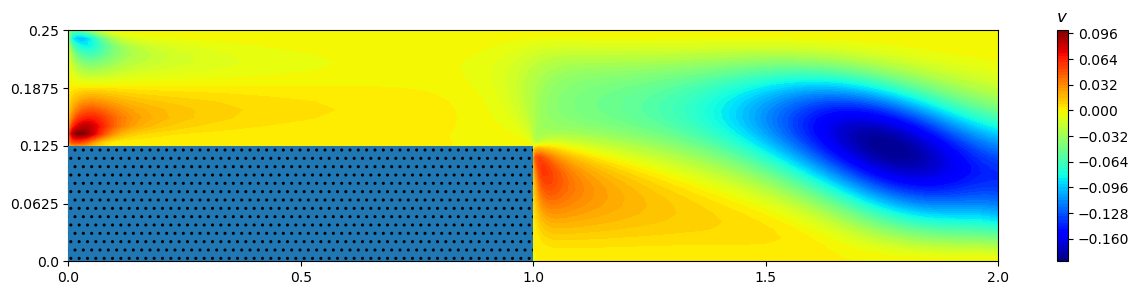

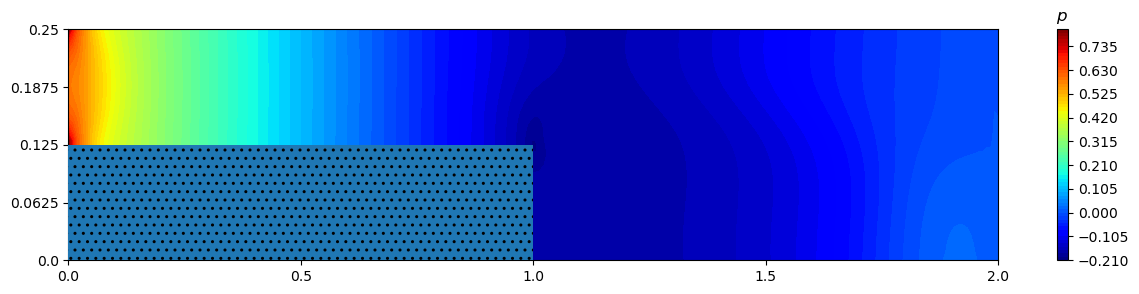

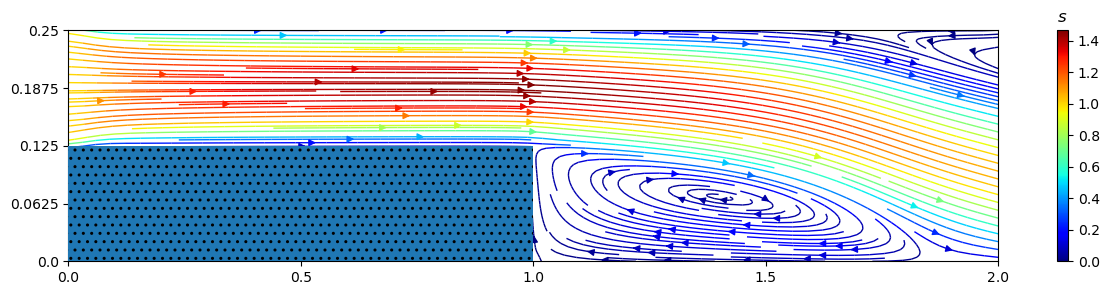

In [406]:

n5.plot('u', levels=80, streamlines=0, figsize=(15, 3))
n5.plot('v', levels=80, streamlines=0, figsize=(15, 3))
n5.plot('p', levels=80, streamlines=0, figsize=(15, 3))
n5.plot(None, levels=0, streamlines=2, figsize=(15, 3))

C:\Users\nurei\AppData\Local\Temp\ipykernel_17100\89311302.py:1072: RuntimeWarning: divide by zero encountered in divide
  d_e = np.where(a_e != 0, (1/2) * (self._area_('e') / a_e + d_px), 0)
C:\Users\nurei\AppData\Local\Temp\ipykernel_17100\89311302.py:1073: RuntimeWarning: divide by zero encountered in divide
  d_w = np.where(a_w != 0, (1/2) * (self._area_('w') / a_w + d_px), 0)
C:\Users\nurei\AppData\Local\Temp\ipykernel_17100\89311302.py:1074: RuntimeWarning: divide by zero encountered in divide
  d_n = np.where(a_n != 0, (1/2) * (self._area_('n') / a_n + d_py), 0)
C:\Users\nurei\AppData\Local\Temp\ipykernel_17100\89311302.py:1075: RuntimeWarning: divide by zero encountered in divide
  d_s = np.where(a_s != 0, (1/2) * (self._area_('s') / a_s + d_py), 0)


Iteration: 182, u_err: 6.188e-05, v_err: 5.357e-05, p'_err: 8.233e-05
Finished with total error 0.00019777739932401513
Iteration: 547, u_err: 3.131e-05, v_err: 2.695e-05, p'_err: 4.154e-05
Finished with total error 9.98038134272514e-05
Iteration: 998, u_err: 2.118e-05, v_err: 1.825e-05, p'_err: 2.718e-05
Finished with total error 6.66101082637024e-05


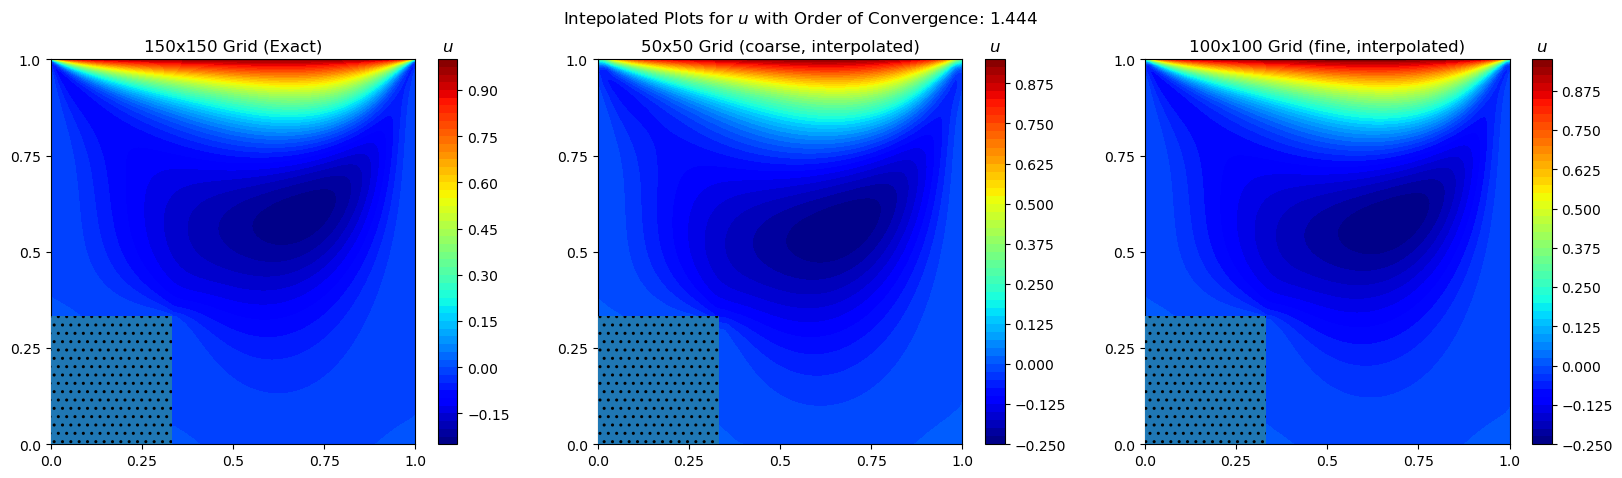

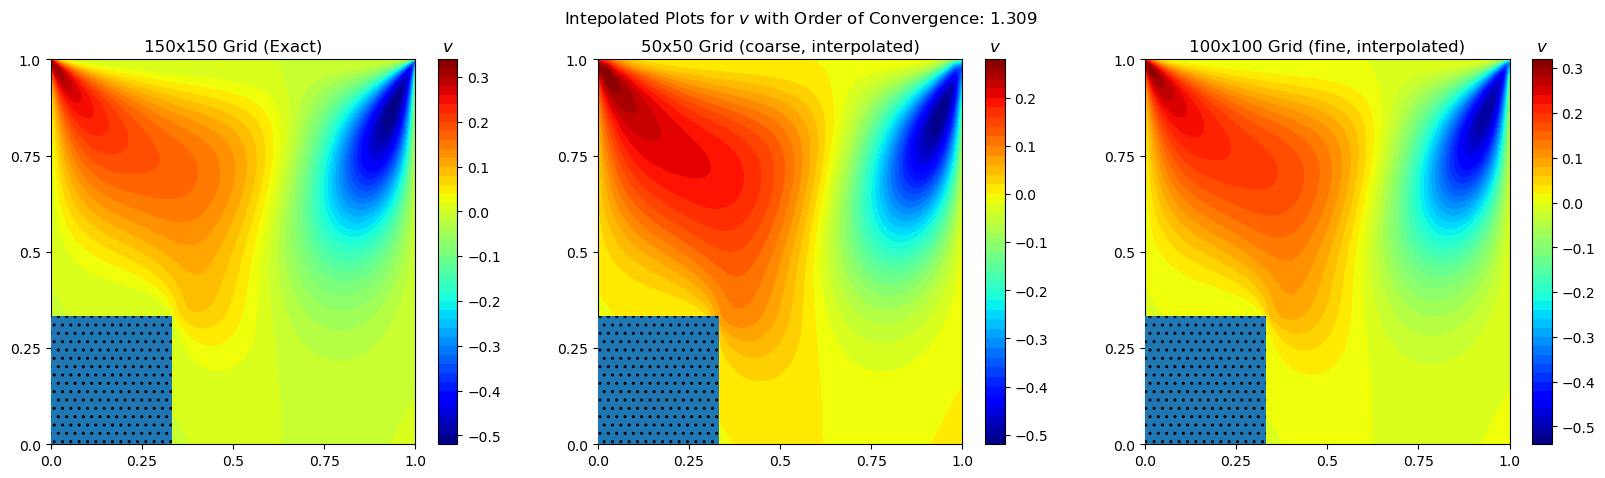

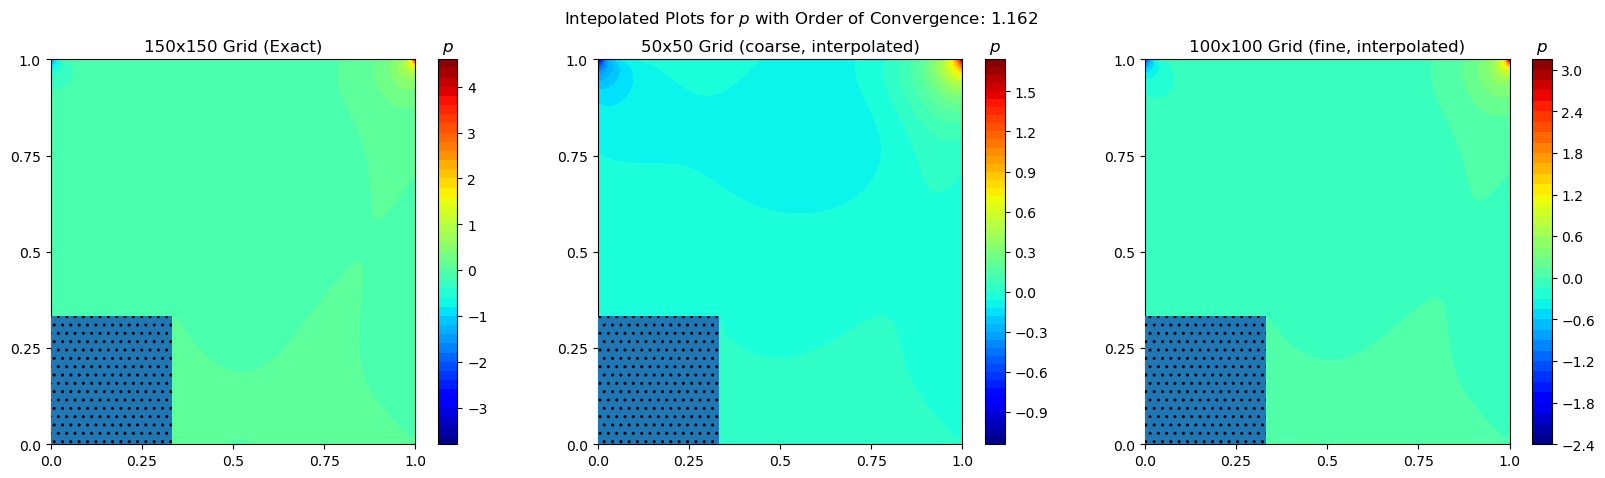

[1.4441355293220963, 1.308634348955109, 1.1623189561385605]


In [ ]:
n6 = NavierStokesSolver(
    u=None, n_cols=150, n_rows=150,
    L_x=1,
    L_y=1,
    Re=100, 
    alpha_m=0.7, 
    alpha_p=0.3, 
    scheme='hybrid', 
    obstacle_coords=[((0,0), (1/3, 1/3))],
    u_B = (0,0,1,0), 
    v_B=(0,0,0,0), 
    phi_B = (10, 100, 100, None))

order = n6.order_conv(objective='uvp', exact_res=150, fine_res=100, coarse_res=50)   
print(order)

C:\Users\nurei\AppData\Local\Temp\ipykernel_17100\3645605726.py:1072: RuntimeWarning: divide by zero encountered in divide
  d_e = np.where(a_e != 0, (1/2) * (self._area_('e') / a_e + d_px), 0)
C:\Users\nurei\AppData\Local\Temp\ipykernel_17100\3645605726.py:1073: RuntimeWarning: divide by zero encountered in divide
  d_w = np.where(a_w != 0, (1/2) * (self._area_('w') / a_w + d_px), 0)
C:\Users\nurei\AppData\Local\Temp\ipykernel_17100\3645605726.py:1074: RuntimeWarning: divide by zero encountered in divide
  d_n = np.where(a_n != 0, (1/2) * (self._area_('n') / a_n + d_py), 0)
C:\Users\nurei\AppData\Local\Temp\ipykernel_17100\3645605726.py:1075: RuntimeWarning: divide by zero encountered in divide
  d_s = np.where(a_s != 0, (1/2) * (self._area_('s') / a_s + d_py), 0)


Iteration: 321, u_err: 5.945e-06, v_err: 5.308e-06, p'_err: 8.459e-06
Finished with total error 1.97125309581968e-05
Iteration: 1088, u_err: 2.991e-06, v_err: 2.630e-06, p'_err: 4.359e-06
Finished with total error 9.98055028243963e-06
Iteration: 2223, u_err: 1.996e-06, v_err: 1.745e-06, p'_err: 2.922e-06
Finished with total error 6.662957006819875e-06


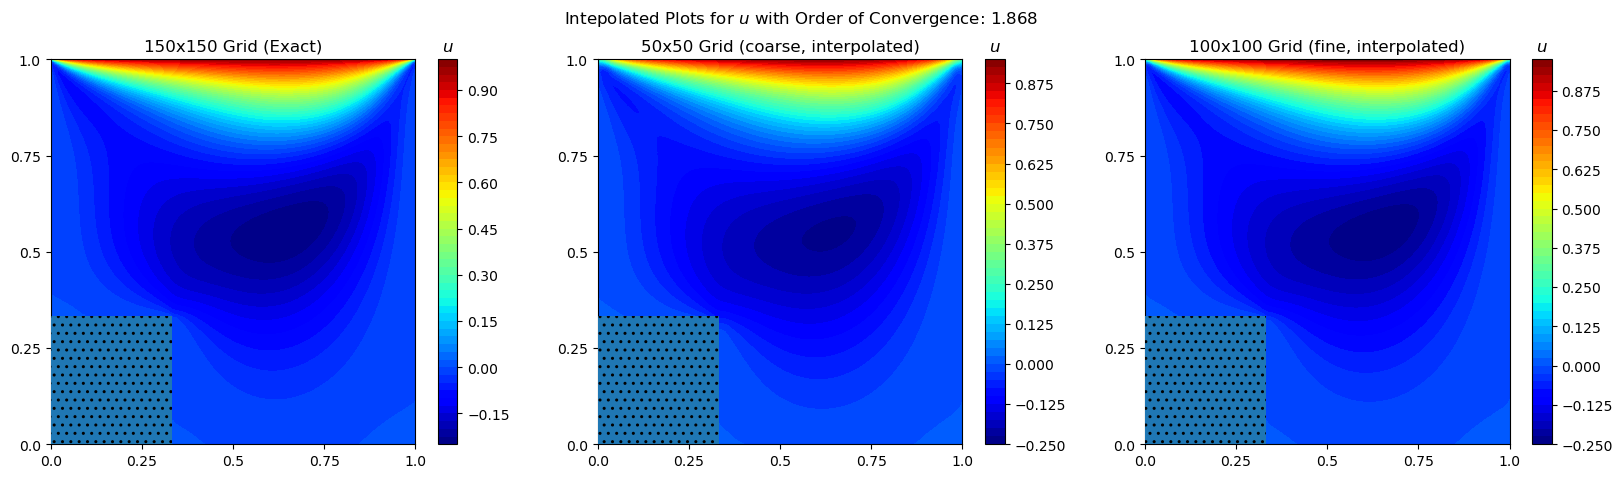

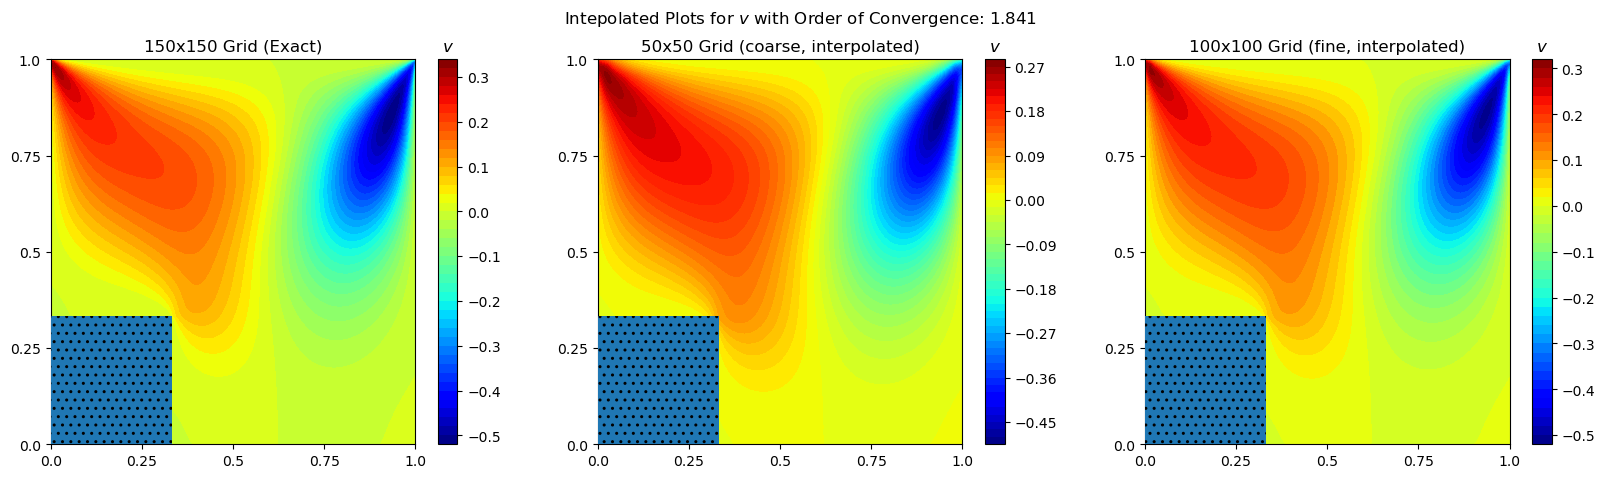

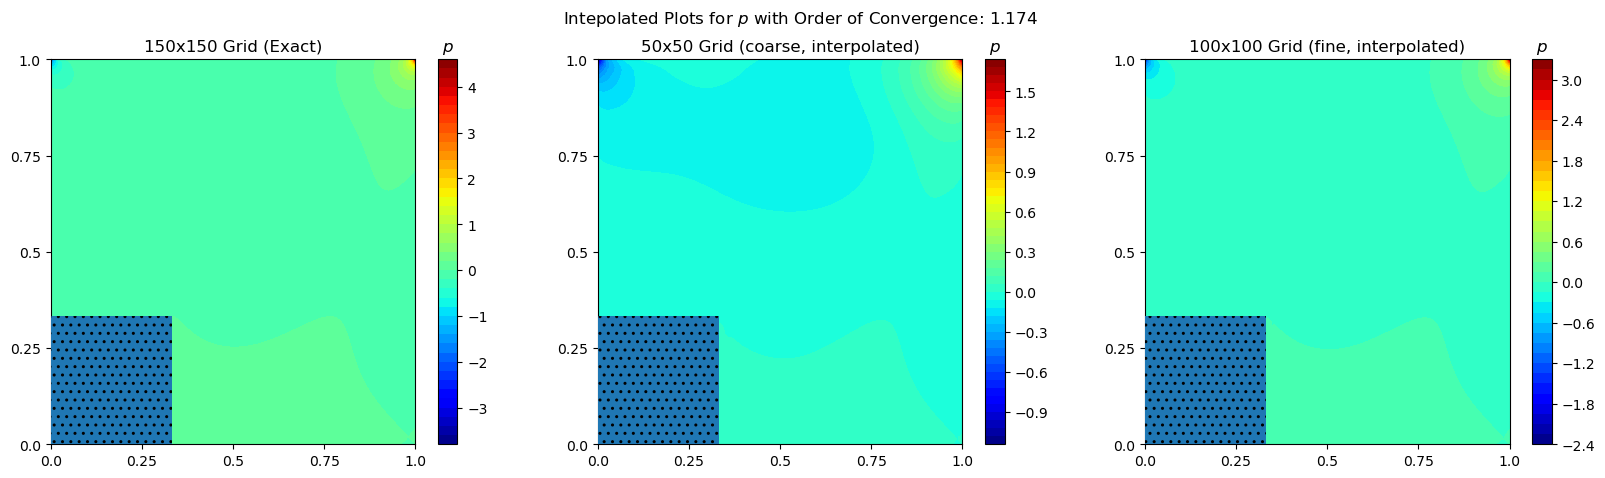

[1.8677942610304525, 1.8411993644983669, 1.1736607343245407]


In [83]:
n6 = NavierStokesSolver(
    u=None, n_cols=150, n_rows=150,
    L_x=1,
    L_y=1,
    Re=100, 
    alpha_m=0.7, 
    alpha_p=0.3, 
    scheme='upwind', 
    obstacle_coords=[((0,0), (1/3, 1/3))],
    u_B = (0,0,1,0), 
    v_B=(0,0,0,0), 
    phi_B = (10, 100, 100, None))

order = n6.order_conv(objective='uvp', exact_res=150, fine_res=100, coarse_res=50)   
print(order)

C:\Users\nurei\AppData\Local\Temp\ipykernel_17100\258939788.py:1073: RuntimeWarning: divide by zero encountered in divide
  d_e = np.where(a_e != 0, (1/2) * (self._area_('e') / a_e + d_px), 0)
C:\Users\nurei\AppData\Local\Temp\ipykernel_17100\258939788.py:1074: RuntimeWarning: divide by zero encountered in divide
  d_w = np.where(a_w != 0, (1/2) * (self._area_('w') / a_w + d_px), 0)
C:\Users\nurei\AppData\Local\Temp\ipykernel_17100\258939788.py:1075: RuntimeWarning: divide by zero encountered in divide
  d_n = np.where(a_n != 0, (1/2) * (self._area_('n') / a_n + d_py), 0)
C:\Users\nurei\AppData\Local\Temp\ipykernel_17100\258939788.py:1076: RuntimeWarning: divide by zero encountered in divide
  d_s = np.where(a_s != 0, (1/2) * (self._area_('s') / a_s + d_py), 0)


Iteration: 524, u_err: 1.818e-07, v_err: 1.639e-07, p'_err: 6.521e-07
Finished with total error 9.97876823993765e-07


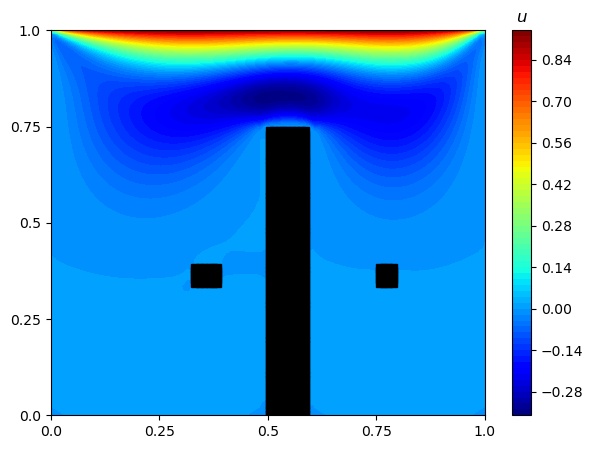

In [ ]:
n7 = NavierStokesSolver(
    u=None, n_cols=100, n_rows=100,
    L_x=1,
    L_y=1,
    Re=100, 
    alpha_m=0.7, 
    alpha_p=0.3, 
    scheme='upwind', 
    obstacle_coords=[((1/3,1/3), (2/5, 2/5)), ((3/4,1/3), (4/5, 2/5)), ((1/2, 0), (0.6, 3/4))],
    u_B = (0,0,1,0), 
    v_B=(0,0,0,0), 
    phi_B = (10, 100, 100, None))

n7.solve('m', threshold=1e-4)   
n7.plot('u', levels=80, streamlines=0)

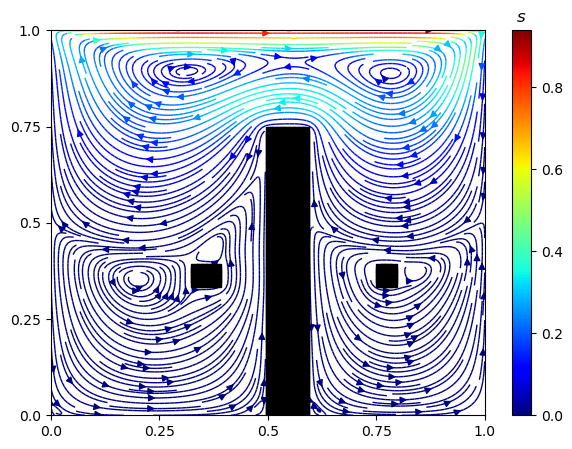

In [110]:
n7.plot(None, levels=50, streamlines=3)

In [6]:
n8 = NavierStokesSolver(
    u=None, n_cols=240, n_rows=30,
    L_x=8,
    L_y=1,
    Re=100, 
    alpha_m=0.7, 
    alpha_p=0.3, 
    scheme='upwind', 
    obstacle_coords=[((0.2 * 8,0), (0.3 * 8, 0.5)), ((3,0.5), (3.5, 0.75)), ((0.5 * 8,0.25), (0.6 * 8, 1)), ((0.8 * 8, 0), ( 8, 0.5))],
    u_B=(None,1,0,0), 
    v_B=(None, 0,0,0),
    p_B=(0, None, None, None),
    phi_B = (10, 100, 100, None))

n8.solve('m', threshold=1e-4)   


c:\Users\nurei\Documents\MIE\MIE1210\a4\navierstokes.py:1086: RuntimeWarning: divide by zero encountered in divide
  d_e = np.where(a_e != 0, (1/2) * (self._area_('e') / a_e + d_px), 0)
c:\Users\nurei\Documents\MIE\MIE1210\a4\navierstokes.py:1087: RuntimeWarning: divide by zero encountered in divide
  d_w = np.where(a_w != 0, (1/2) * (self._area_('w') / a_w + d_px), 0)
c:\Users\nurei\Documents\MIE\MIE1210\a4\navierstokes.py:1088: RuntimeWarning: divide by zero encountered in divide
  d_n = np.where(a_n != 0, (1/2) * (self._area_('n') / a_n + d_py), 0)
c:\Users\nurei\Documents\MIE\MIE1210\a4\navierstokes.py:1089: RuntimeWarning: divide by zero encountered in divide
  d_s = np.where(a_s != 0, (1/2) * (self._area_('s') / a_s + d_py), 0)


Iteration: 267, u_err: 2.760e-07, v_err: 1.459e-07, p'_err: 2.787e-06
Finished with total error 3.209062895880387e-06


(array([[  nan, 0.   , 0.   , ..., 0.   , 0.   ,   nan],
        [1.   , 0.846, 0.769, ..., 0.409, 0.401, 0.402],
        [1.   , 1.011, 1.03 , ..., 1.149, 1.137, 1.14 ],
        ...,
        [1.   , 1.011, 1.029, ...,   nan,   nan,   nan],
        [1.   , 0.846, 0.768, ...,   nan,   nan,   nan],
        [  nan, 0.   , 0.   , ...,   nan,   nan,   nan]]),
 2.76006261324192e-07,
 array([[   nan,  0.   ,  0.   , ...,  0.   ,  0.   ,    nan],
        [ 0.   , -0.1  , -0.105, ..., -0.   , -0.001, -0.001],
        [ 0.   , -0.161, -0.187, ..., -0.004, -0.005, -0.005],
        ...,
        [ 0.   ,  0.161,  0.189, ...,    nan,    nan,    nan],
        [ 0.   ,  0.101,  0.106, ...,    nan,    nan,    nan],
        [   nan,  0.   ,  0.   , ...,    nan,    nan,    nan]]),
 1.4592084153052512e-07,
 array([[   nan, 31.755, 31.285, ...,  0.027,  0.   ,    nan],
        [31.755, 31.755, 31.285, ...,  0.027,  0.   ,  0.   ],
        [31.353, 31.353, 31.183, ...,  0.029,  0.   ,  0.   ],
        ...,


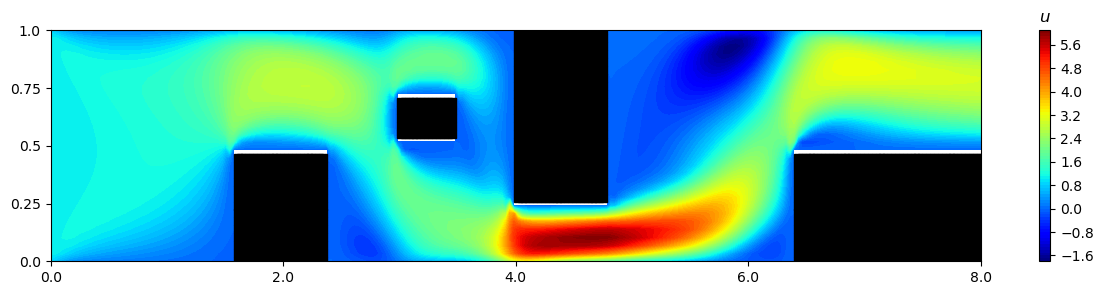

In [2]:
n8.plot('u', levels=80, streamlines=0, figsize=(15, 3))

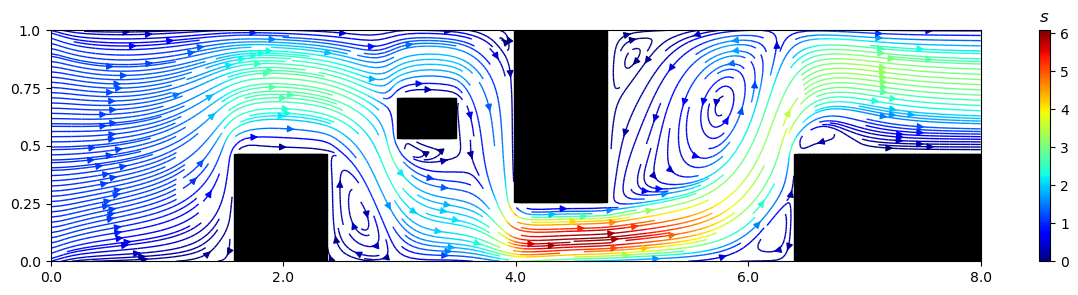

In [7]:
n8.plot(None, levels=0, streamlines=3, figsize=(15, 3))